In [1]:

%load_ext autoreload
%autoreload 2

import ezy_seq as ezy
#import ezy_seq.load 
import scanpy as sc
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt

c:\Users\woods\miniconda3\envs\new_env\lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\woods\miniconda3\envs\new_env\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [18]:
 %reload_ext autoreload

In [2]:
adata_full=sc.read_h5ad(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\Vignette_project\H5ADs\napari_updated.h5ad")
#adata_full=adata_full1[adata_full1.obs['napari_region']!='Brain_Stem']
adata_full.obs['napari_region'].unique()
#adata=adata_full.copy()

['Cerebellum', 'Unassigned', 'Brain_Stem', 'Hippocampus', 'Cortex']
Categories (5, object): ['Brain_Stem', 'Cerebellum', 'Cortex', 'Hippocampus', 'Unassigned']

In [ ]:

import os
import pandas as pd
import numpy as np
from scipy.io import mmwrite

folder = r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\Vignette_project\seurat_construct"

# --- features (genes)
adata_full.var.to_csv(os.path.join(folder, "features_counts.csv"))

# --- cell metadata
adata_full.obs.to_csv(os.path.join(folder, "cell_metadata.csv"))

# --- main expression matrices ---
# logged data
logged_df = pd.DataFrame(
    adata_full.X.toarray(), 
    index=adata_full.obs_names,
    columns=adata_full.var_names
)
logged_df.to_csv(os.path.join(folder, "logged_counts.csv"))

# raw counts
raw_df = pd.DataFrame(
    adata_full.layers["counts"].toarray(),
    index=adata_full.obs_names,
    columns=adata_full.var_names
)
raw_df.to_csv(os.path.join(folder, "raw_counts.csv"))



# --- coordinates ---
coords = pd.DataFrame(
    adata_full.obsm["spatial_fov"],  # adjust key if needed
    index=adata_full.obs_names,
    columns=["x", "y"]
)
coords.to_csv(os.path.join(folder, "coords_xy.csv"))

print("✅ Saved: counts.mtx, features_counts.csv, cell_metadata.csv, logged_counts.csv, raw_counts.csv, coords_xy.csv")


AttributeError: 'numpy.ndarray' object has no attribute 'toarray'

In [7]:
coords = pd.DataFrame(
    adata_full.obsm["spatial_fov"],  # adjust key if needed
    index=adata_full.obs_names,
    columns=["x", "y"]
)
coords.to_csv(os.path.join(folder, "coords_xy.csv"))

print("✅ Saved: counts.mtx, features_counts.csv, cell_metadata.csv, logged_counts.csv, raw_counts.csv, coords_xy.csv")

✅ Saved: counts.mtx, features_counts.csv, cell_metadata.csv, logged_counts.csv, raw_counts.csv, coords_xy.csv


In [39]:
import pandas as pd
import numpy as np
from statsmodels.regression.mixed_linear_model import MixedLM
from tqdm import tqdm
from scipy import sparse

def lmm_per_gene(
    adata,
    group_col: str,      # e.g. "FMT"
    subject_col: str,    # e.g. "subject_id"
    genes: list = None,
    layer: str = None,   # e.g. "lognorm" or "counts"
    subset_query: str = None, # e.g. "cell_type == 'Astro'"
):
    """
    Fit per-gene linear mixed models using statsmodels MixedLM.
    """
    # --- data selection ---
    ad = adata.copy()
    if subset_query:
        ad = ad[ad.obs.query(subset_query).index]

    Xmat = (
        ad.layers[layer]
        if layer and layer in ad.layers
        else ad.X
    )
    if sparse.issparse(Xmat):
        Xmat = Xmat.toarray()

    obs = ad.obs.copy()
    if genes is None:
        genes = ad.var_names

    results = []
    for x,g in enumerate(tqdm(genes, desc="Fitting LMMs")):
        print(x, "out of", len(genes))
        y = Xmat[:, ad.var_names.get_loc(g)]
        df = pd.DataFrame({
            "y": y,
            "group": obs[group_col].astype("category"),
            "subject": obs[subject_col].astype("category"),
        })
        try:
            model = MixedLM.from_formula("y ~ group", groups="subject", data=df)
            fit = model.fit(reml=False)
            results.append({
                "gene": g,
                "coef_group": fit.params.get("group[T.1]", np.nan) if "group[T.1]" in fit.params else np.nan,
                "pval_group": fit.pvalues.get("group[T.1]", np.nan),
                "var_subject": fit.cov_re.iloc[0, 0] if fit.cov_re is not None else np.nan,
                "aic": fit.aic
            })
        except Exception as e:
            results.append({"gene": g, "coef_group": np.nan, "pval_group": np.nan, "var_subject": np.nan, "aic": np.nan})
    return pd.DataFrame(results)

# Example use:
df_res = lmm_per_gene(adata_full, group_col="FMT", subject_col="sample_ID", layer=None)
df_res.to_csv("DE_mixed_model_results.csv", index=False)


Fitting LMMs:   0%|          | 0/1000 [00:00<?, ?it/s]

0 out of 1000


Fitting LMMs:   0%|          | 0/1000 [00:08<?, ?it/s]


KeyboardInterrupt: 

In [62]:
adata_full.obs['tissue'].unique()

['Cerebellum', NaN, 'Cortex', 'Hippocampus']
Categories (3, object): ['Cerebellum', 'Cortex', 'Hippocampus']

In [23]:
adata.counts

AttributeError: 'AnnData' object has no attribute 'counts'

on the else cond.
[['Stroke_FMT', 'Healthy_FMT']]
on the else cond.
[['Stroke_FMT', 'Healthy_FMT']]
on the else cond.
[['Stroke_FMT', 'Healthy_FMT']]
on the else cond.
[['Stroke_FMT', 'Healthy_FMT']]


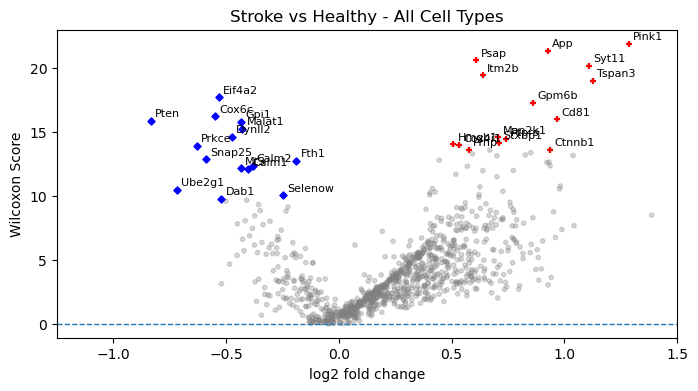

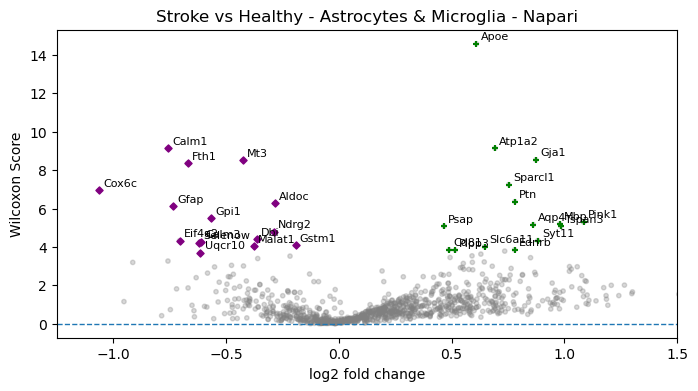

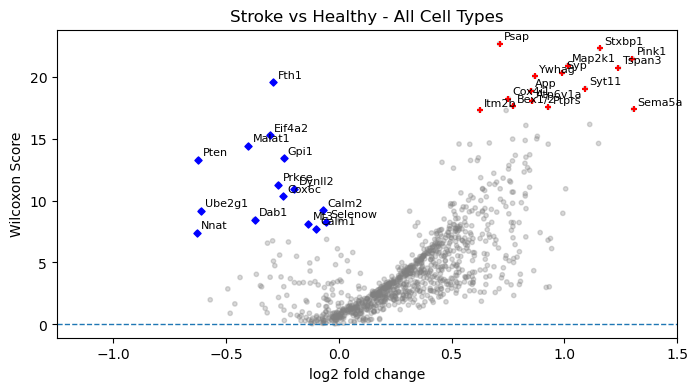

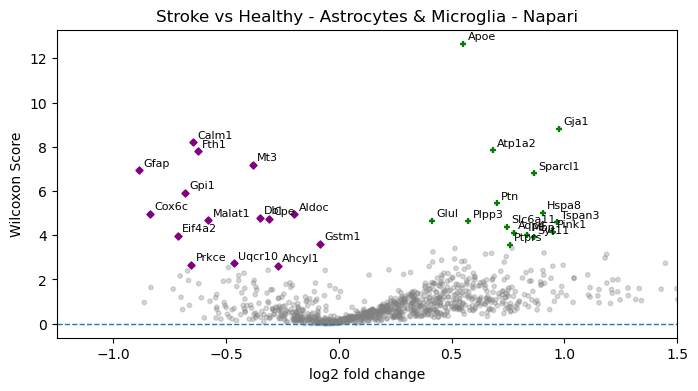

<Figure size 800x300 with 0 Axes>

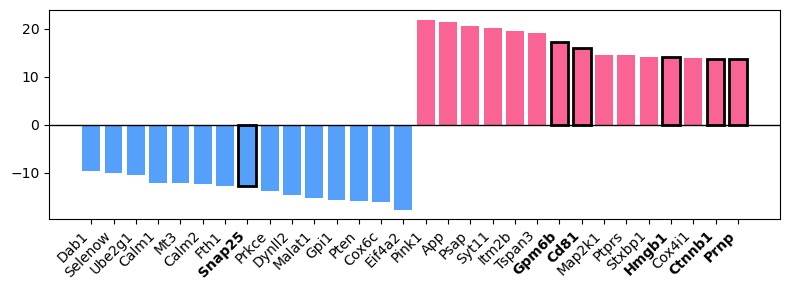

<Figure size 800x300 with 0 Axes>

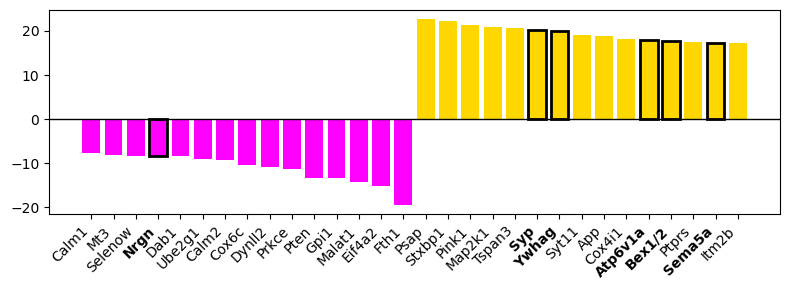

1


<Figure size 800x300 with 0 Axes>

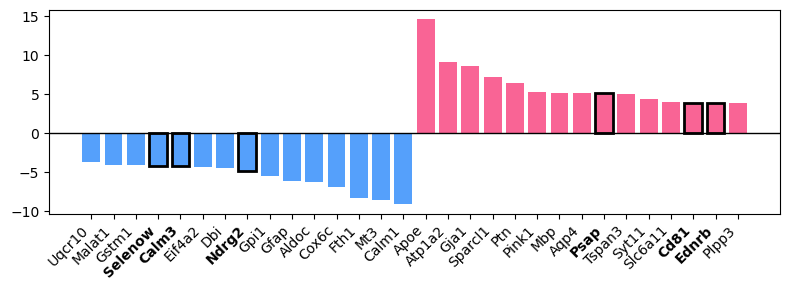

<Figure size 800x300 with 0 Axes>

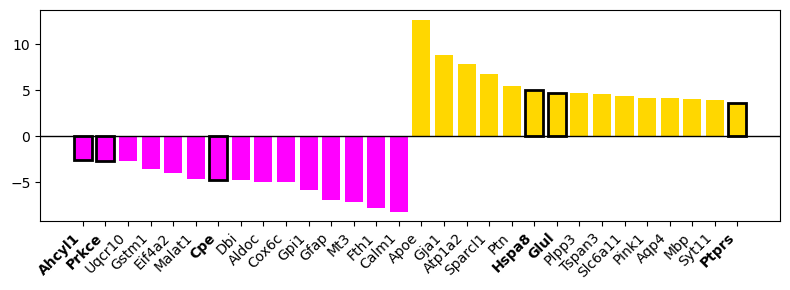

'\nezy.plot.feats_bar(Hippocampus_fov_genes,variable=\'-log10p\',orientation=\'horizontal\',fig_size=(8,3),num_feats=30,bold_genes=all_cells_delta,title=\'\')\nezy.plot.feats_bar(Hippocampus_napari_genes,variable=\'-log10p\',orientation=\'horizontal\',fig_size=(8,3),num_feats=30,bold_genes=all_cells_delta,colors=[\'magenta\',\'gold\'],title=\'\')\nprint("1")\nezy.plot.feats_bar(Hippocampus_fov_genes_A,variable=\'-log10p\',orientation=\'horizontal\',fig_size=(8,3),num_feats=30,bold_genes=astro_delta,title=\'\')\nezy.plot.feats_bar(Hippocampus_napari_genes_A,variable=\'-log10p\',orientation=\'horizontal\',fig_size=(8,3),num_feats=30,bold_genes=astro_delta,colors=[\'magenta\',\'gold\'],title=\'\')\n'

In [41]:
adata_full=adata_full_complete[(adata_full_complete.obs['sample_ID']=='120L') |(adata_full_complete.obs['sample_ID']=='323DY') ]
gene_num=30
roi='Hippocampus'
Hippocampus_fov_genes=ezy.rank_DE(
    adata_full[adata_full.obs['tissue']==roi],
    groupby="FMT",
    comparisons=[['Stroke_FMT','Healthy_FMT']],
    #extra_filter={"cell_type": ["Astro","Micro.PVM"]}  # optional extra filters
)
Hippocampus_fov_genes_A=ezy.rank_DE(
    adata_full[adata_full.obs['tissue']==roi],
    groupby="FMT",
    comparisons=[['Stroke_FMT','Healthy_FMT']],
    extra_filter={"cell_type": ["Astro"]}  # optional extra filters
)

Hippocampus_napari_genes=ezy.rank_DE(
    adata_full[adata_full.obs['napari_region']==roi],
    groupby="FMT",
    comparisons=[['Stroke_FMT','Healthy_FMT']],
   # extra_filter={"cell_type": ["Astro"]}  # optional extra filters
)
Hippocampus_napari_genes_A=ezy.rank_DE(
    adata_full[adata_full.obs['napari_region']==roi],
    groupby="FMT",
    comparisons=[['Stroke_FMT','Healthy_FMT']],
    extra_filter={"cell_type": ["Astro"]}  # optional extra filters
)

y_axis_metric='score'
t1=ezy.plot.volcano(Hippocampus_fov_genes,y_axis=y_axis_metric,default_colors=['grey','grey'],balance_labels=True,
                significant_colors=['red','blue'],
                return_highlights=True,
                top_labels=gene_num,
                figsize=(8,4),
                sig_markers=["+","D"],
                x_range=[-1.25,1.5],
           
    
                title='Stroke vs Healthy - All Cell Types')
t2=ezy.plot.volcano(Hippocampus_fov_genes_A,y_axis=y_axis_metric,default_colors=['grey','grey'],balance_labels=True,
                significant_colors=['green','purple'],
                return_highlights=True,
                top_labels=gene_num,
                figsize=(8,4),
                sig_markers=["+","D"],
                x_range=[-1.25,1.5],
            

                title='Stroke vs Healthy - Astrocytes & Microglia - Napari')
t3=ezy.plot.volcano(Hippocampus_napari_genes,y_axis=y_axis_metric,default_colors=['grey','grey'],balance_labels=True,
                significant_colors=['red','blue'],
                return_highlights=True,
                top_labels=gene_num,
                figsize=(8,4),
                sig_markers=["+","D"],
                x_range=[-1.25,1.5],
            

                title='Stroke vs Healthy - All Cell Types')
t4=ezy.plot.volcano(Hippocampus_napari_genes_A,y_axis=y_axis_metric,default_colors=['grey','grey'],balance_labels=True,
                significant_colors=['green','purple'],
                return_highlights=True,
                top_labels=gene_num,
                figsize=(8,4),
                sig_markers=["+","D"],
                x_range=[-1.25,1.5],
                title='Stroke vs Healthy - Astrocytes & Microglia - Napari')

def get_deltas(up_df, down_df, n=20):
    """Return symmetric difference of top-n genes by |score| between up and down."""
    k_up = n // 2
    k_dn = n - k_up

    # Top up-regulated (largest positive scores)
    up_up   = up_df.sort_values('score', ascending=False).head(k_up)['gene']
    down_up = down_df.sort_values('score', ascending=False).head(k_up)['gene']

    # Top down-regulated (most negative scores)
    up_dn   = up_df.sort_values('score', ascending=True).head(k_dn)['gene']
    down_dn = down_df.sort_values('score', ascending=True).head(k_dn)['gene']

    deltas_up   = list(set(up_up) ^ set(down_up))
    deltas_down = list(set(up_dn) ^ set(down_dn))
    return deltas_up + deltas_down

all_cells_delta=get_deltas(Hippocampus_fov_genes,Hippocampus_napari_genes,n=30)
astro_delta=get_deltas(Hippocampus_fov_genes_A,Hippocampus_napari_genes_A,n=30)


ezy.plot.feats_bar(Hippocampus_fov_genes,orientation='horizontal',fig_size=(8,3),num_feats=30,bold_genes=all_cells_delta,title='')
ezy.plot.feats_bar(Hippocampus_napari_genes,orientation='horizontal',fig_size=(8,3),num_feats=30,bold_genes=all_cells_delta,colors=['magenta','gold'],title='')
print("1")
ezy.plot.feats_bar(Hippocampus_fov_genes_A,orientation='horizontal',fig_size=(8,3),num_feats=30,bold_genes=astro_delta,title='')
ezy.plot.feats_bar(Hippocampus_napari_genes_A,orientation='horizontal',fig_size=(8,3),num_feats=30,bold_genes=astro_delta,colors=['magenta','gold'],title='')
r'''
ezy.plot.feats_bar(Hippocampus_fov_genes,variable='-log10p',orientation='horizontal',fig_size=(8,3),num_feats=30,bold_genes=all_cells_delta,title='')
ezy.plot.feats_bar(Hippocampus_napari_genes,variable='-log10p',orientation='horizontal',fig_size=(8,3),num_feats=30,bold_genes=all_cells_delta,colors=['magenta','gold'],title='')
print("1")
ezy.plot.feats_bar(Hippocampus_fov_genes_A,variable='-log10p',orientation='horizontal',fig_size=(8,3),num_feats=30,bold_genes=astro_delta,title='')
ezy.plot.feats_bar(Hippocampus_napari_genes_A,variable='-log10p',orientation='horizontal',fig_size=(8,3),num_feats=30,bold_genes=astro_delta,colors=['magenta','gold'],title='')
'''

In [81]:
Hippocampus_fov_genes

,gene,log2fc,score,p,padj,target,neglog10p,ref
0,Pink1,1.286213,21.905663,2.294246e-106,2.294246e-103,Stroke_FMT,102.639360,Healthy_FMT
1,App,0.926768,21.334616,5.418841e-101,2.709420e-98,Stroke_FMT,97.567124,Healthy_FMT
2,Psap,0.610165,20.623293,1.696095e-94,5.653650e-92,Stroke_FMT,91.247671,Healthy_FMT
3,Syt11,1.108142,20.164104,2.023736e-90,5.059341e-88,Stroke_FMT,87.295906,Healthy_FMT
4,Itm2b,0.638943,19.428036,4.471478e-84,8.942956e-82,Stroke_FMT,81.048519,Healthy_FMT
...,...,...,...,...,...,...,...,...
995,Malat1,-0.428088,-15.263622,1.336201e-52,1.027847e-50,Stroke_FMT,49.988072,Healthy_FMT
996,Gpi1,-0.434920,-15.791846,3.540639e-56,2.950532e-54,Stroke_FMT,53.530100,Healthy_FMT
997,Pten,-0.832574,-15.890730,7.346754e-57,6.678867e-55,Stroke_FMT,54.175297,Healthy_FMT
998,Cox6c,-0.548031,-16.225868,3.310088e-59,3.677875e-57,Stroke_FMT,56.434403,Healthy_FMT


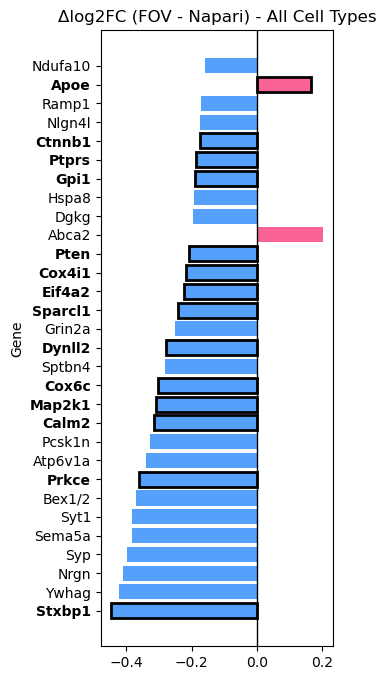

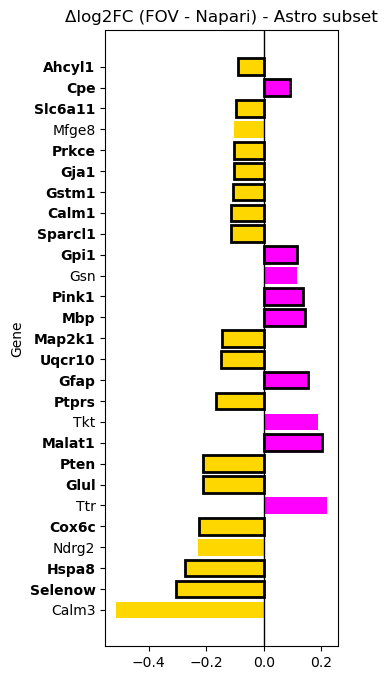

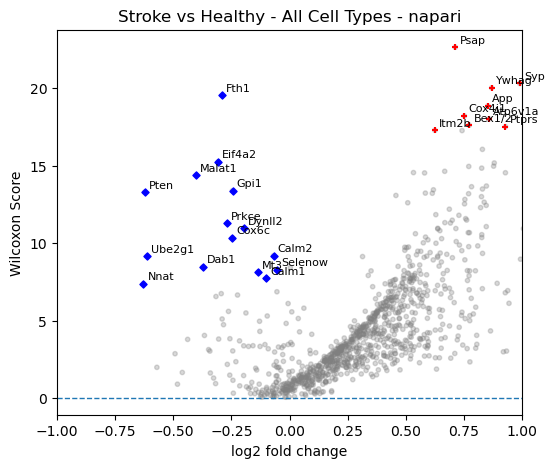

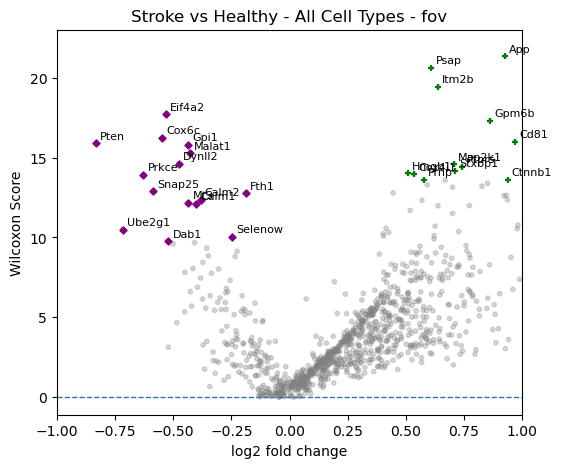

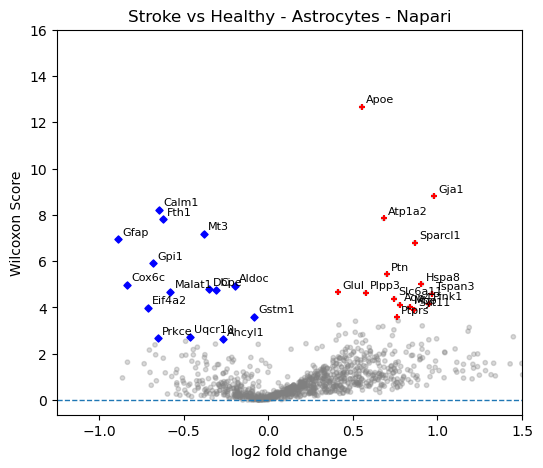

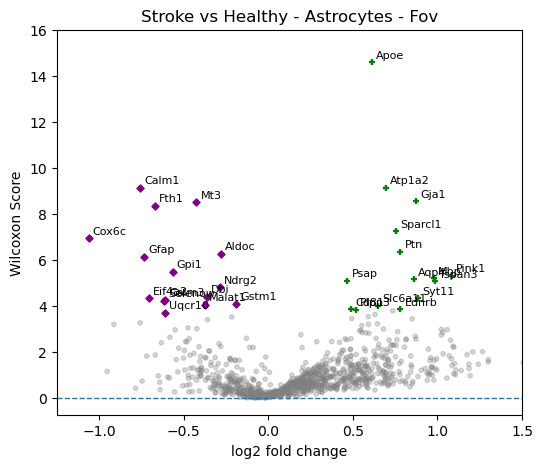

In [53]:
# ---------------------------------------------------------
# Largest changes in log2FC between FOV vs Napari
# ---------------------------------------------------------
y_axis_metric='neglog10p'
y_axis_metric='score'
def get_lfc_deltas(df_fov, df_nap, n=30):
    """
    Find genes with the largest |Δlog2fc| between FOV and Napari results.

    Returns a small DataFrame with:
      gene, log2fc_fov, log2fc_nap, delta_log2fc, abs_delta_log2fc
    """
    # Keep only gene + log2fc and align by gene
    fov = df_fov[['gene', 'log2fc', 'score','neglog10p']].rename(columns={'log2fc': 'log2fc_fov', 'score': 'score_fov','neglog10p':'neglog10p_fov'})
    nap = df_nap[['gene', 'log2fc', 'score','neglog10p']].rename(columns={'log2fc': 'log2fc_nap', 'score': 'score_nap','neglog10p':'neglog10p_nap'})
    merged = fov.merge(nap, on='gene', how='inner')

    # --- NEW LINES ---
    merged = merged[(merged['score_fov'].abs() > 3) | (merged['score_nap'].abs() > 3)]

    # Compute differences
    merged['delta_log2fc'] = merged['log2fc_fov'] - merged['log2fc_nap']
    merged['abs_delta_log2fc'] = merged['delta_log2fc'].abs()

    # Top n by absolute delta
    return merged.sort_values('abs_delta_log2fc', ascending=False).head(n)

# --- all cell types ---
all_cells_lfc_delta = get_lfc_deltas(
    #Hippocampus_fov_genes,
    #Hippocampus_napari_genes,
    Hippocampus_fov_genes[Hippocampus_fov_genes['neglog10p']>15 ],
    Hippocampus_napari_genes[Hippocampus_napari_genes['neglog10p']>15],
    n=30
)

# --- astrocytes (and microglia in the FOV version, per your filter) ---
astro_lfc_delta = get_lfc_deltas(
    Hippocampus_fov_genes_A,
    Hippocampus_napari_genes_A,
    n=30
)

r'''print("Top Δlog2FC genes (all cells):")
print(all_cells_lfc_delta[['gene', 'log2fc_fov', 'log2fc_nap', 'delta_log2fc','score_fov','score_nap']])

print("\nTop Δlog2FC genes (astro subset):")
print(astro_lfc_delta[['gene', 'log2fc_fov', 'log2fc_nap', 'delta_log2fc','score_fov','score_nap']])
'''
# Optional: visualize Δlog2FC using your feats_bar helper
pass1=list(pd.concat([t1[0],t1[1],t2[0],t2[1]])['gene'])
ezy.plot.feats_bar(
    all_cells_lfc_delta[(all_cells_lfc_delta['neglog10p_fov']>15) | (all_cells_lfc_delta['neglog10p_nap']>15)],
    variable='delta_log2fc',
    orientation='vertical',
    fig_size=(3, 8),
    num_feats=30,
    bold_genes=pass1,
    title='Δlog2FC (FOV - Napari) - All Cell Types'
)
pass2=list(pd.concat([t4[0],t4[1],t3[0],t3[1]])['gene'])
ezy.plot.feats_bar(
    astro_lfc_delta[(astro_lfc_delta['neglog10p_fov']>1.3) | (astro_lfc_delta['neglog10p_nap']>1.3)],
    variable='delta_log2fc',
    orientation='vertical',
    fig_size=(3, 8),
    num_feats=30,
    colors=['gold','magenta'],

    bold_genes=pass2,
    title='Δlog2FC (FOV - Napari) - Astro subset'
)


napari_hip=ezy.plot.volcano(Hippocampus_napari_genes,y_axis=y_axis_metric,default_colors=['grey','grey'],balance_labels=True,
                significant_colors=['red','blue'],
                return_highlights=True,
                top_labels=gene_num,
                figsize=(6,5),
                sig_markers=["+","D"],
                x_range=[-1,1],
              #  y_max=25,
                title='Stroke vs Healthy - All Cell Types - napari')

fov_hip=ezy.plot.volcano(Hippocampus_fov_genes,y_axis=y_axis_metric,default_colors=['grey','grey'],balance_labels=True,
                significant_colors=['green','purple'],
                return_highlights=True,
                top_labels=gene_num,
                figsize=(6,5),
                sig_markers=["+","D"],
                x_range=[-1,1],
               # y_max=25,
                title='Stroke vs Healthy - All Cell Types - fov')

napari_hip_A=ezy.plot.volcano(Hippocampus_napari_genes_A,y_axis=y_axis_metric,default_colors=['grey','grey'],balance_labels=True,
                significant_colors=['red','blue'],
                return_highlights=True,
                top_labels=gene_num,
                figsize=(6,5),
                sig_markers=["+","D"],
                x_range=[-1.25,1.5],
                y_max=16,
                title='Stroke vs Healthy - Astrocytes - Napari')

fov_hip_A=ezy.plot.volcano(Hippocampus_fov_genes_A,y_axis=y_axis_metric,default_colors=['grey','grey'],balance_labels=True,
                significant_colors=['green','purple'],
                return_highlights=True,
                top_labels=gene_num,
                figsize=(6,5),
                sig_markers=["+","D"],
                x_range=[-1.25,1.5],
                y_max=16,
                title='Stroke vs Healthy - Astrocytes - Fov')




In [49]:
astro_lfc_delta

,gene,log2fc_fov,score_fov,neglog10p_fov,log2fc_nap,score_nap,neglog10p_nap,delta_log2fc,abs_delta_log2fc
989,Calm3,-0.612303,-4.262391,3.036531,-0.097919,-1.106616,0.046792,-0.514384,0.514384
980,Calm2,-0.476077,-3.042715,1.273395,-0.145170,-1.003273,0.031483,-0.330908,0.330908
988,Selenow,-0.618081,-4.231169,2.995342,-0.313013,-2.419342,0.556515,-0.305069,0.305069
16,Hspa8,0.630009,3.629242,2.051443,0.905343,5.011534,4.309017,-0.275334,0.275334
992,Ndrg2,-0.287557,-4.800689,4.056284,-0.060106,-2.408524,0.556515,-0.227450,0.227450
996,Cox6c,-1.062908,-6.942545,9.317520,-0.836024,-4.975744,4.266285,-0.226884,0.226884
20,Ttr,1.669192,3.374054,1.710142,1.448606,2.734087,0.847201,0.220586,0.220586
59,Glul,0.199328,2.195415,0.518225,0.411957,4.665717,3.742543,-0.212628,0.212628
981,Pten,-0.914078,-3.195778,1.478817,-0.703797,-2.160870,0.382018,-0.210281,0.210281
979,Mdh1,-0.422960,-3.010225,1.236481,-0.213587,-1.647150,0.178149,-0.209373,0.209373


adata object length for None is: 601440


c:\Users\woods\miniconda3\envs\new_env\lib\site-packages\scanpy\neighbors\__init__.py:586: UserWarning: You’re trying to run this on 1000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)
c:\Users\woods\miniconda3\envs\new_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


###############################
###############################
tissue
Hippocampus
36356
###############################
###############################


C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\Vignette_project\mypythonlibrary\src\ezy_seq\plot\plot_functions.py:868: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sub.obs[cluster_key] = pd.Categorical(


###############################
###############################
napari_region
Hippocampus
29300
###############################
###############################


C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\Vignette_project\mypythonlibrary\src\ezy_seq\plot\plot_functions.py:868: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sub.obs[cluster_key] = pd.Categorical(


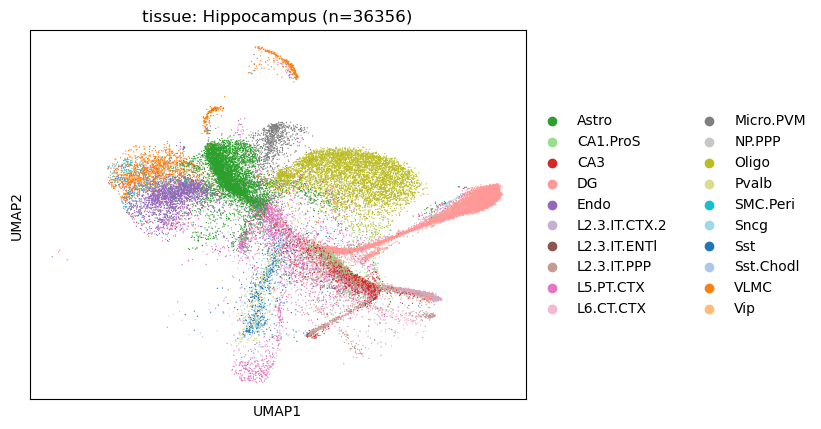

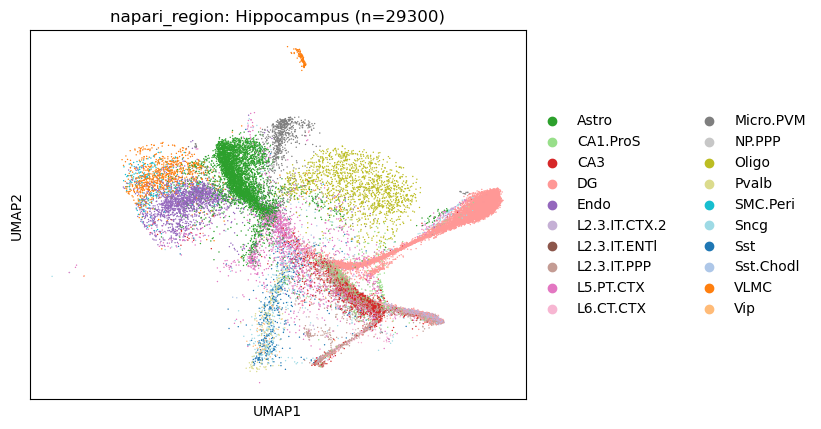

In [5]:
figs=ezy.plot.umap(
    adata= adata_full,
    cluster_key= "cell_type",

    group_by1= "tissue",
    group_by1_list= ["Hippocampus"],

    group_by2= "napari_region",
    group_by2_list= ["Hippocampus"],
    
    n_top_clusters= 20,
    n_neighbors = 25,
    n_pcs = 50,
    random_state = 0,
    legend_fontsize= 10,
    show = True#,
    #save: Optional[str] = None,   # e.g. "umap_by_group.png" or None
)

adata object length for None is: 40432


c:\Users\woods\miniconda3\envs\new_env\lib\site-packages\scanpy\neighbors\__init__.py:586: UserWarning: You’re trying to run this on 1000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


###############################
###############################
tissue
Hippocampus
36918
###############################
###############################


C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\Vignette_project\mypythonlibrary\src\ezy_seq\plot\plot_functions.py:868: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sub.obs[cluster_key] = pd.Categorical(


###############################
###############################
napari_region
Hippocampus
29989
###############################
###############################


C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\Vignette_project\mypythonlibrary\src\ezy_seq\plot\plot_functions.py:868: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sub.obs[cluster_key] = pd.Categorical(


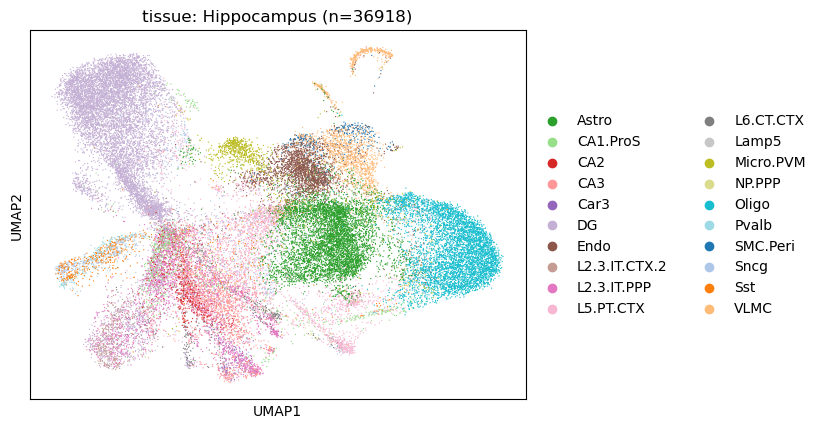

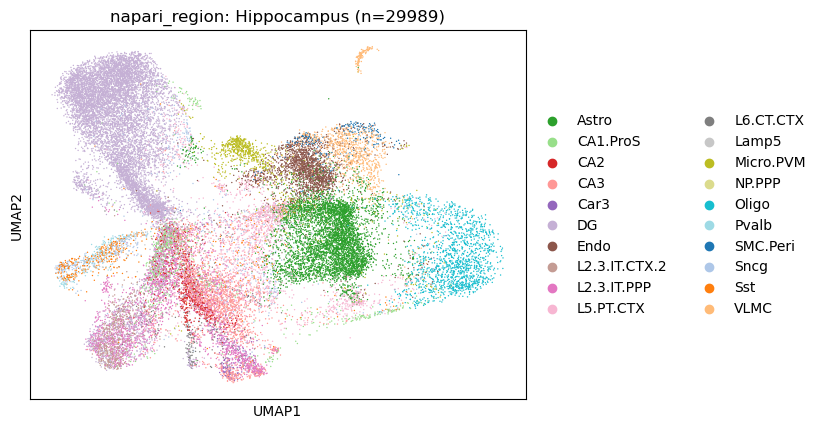

In [ ]:
figs=ezy.plot.umap(
    adata= adata_full[(adata_full.obs['napari_region']=='Hippocampus') | (adata_full.obs['tissue']=='Hippocampus')],
    cluster_key= "cell_type",

    group_by1= "tissue",
    group_by1_list= ["Hippocampus"],

    group_by2= "napari_region",
    group_by2_list= ["Hippocampus"],
    
    n_top_clusters= 20,
    n_neighbors = 25,
    n_pcs = 50,
    random_state = 0,
    legend_fontsize= 10,
    show = True#,
    #save: Optional[str] = None,   # e.g. "umap_by_group.png" or None
)

adata object length for None is: 174721


c:\Users\woods\miniconda3\envs\new_env\lib\site-packages\scanpy\neighbors\__init__.py:586: UserWarning: You’re trying to run this on 1000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


###############################
###############################
tissue
Cortex
147058
###############################
###############################


C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\Vignette_project\mypythonlibrary\src\ezy_seq\plot\plot_functions.py:868: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sub.obs[cluster_key] = pd.Categorical(


###############################
###############################
napari_region
Cortex
141901
###############################
###############################


C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\Vignette_project\mypythonlibrary\src\ezy_seq\plot\plot_functions.py:868: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sub.obs[cluster_key] = pd.Categorical(


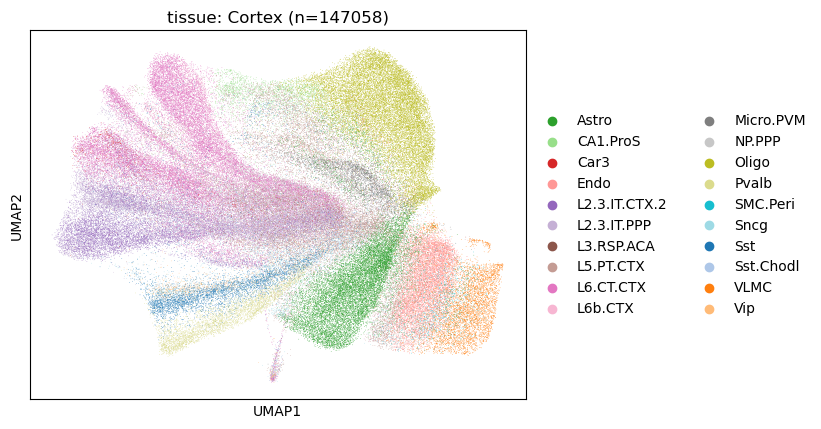

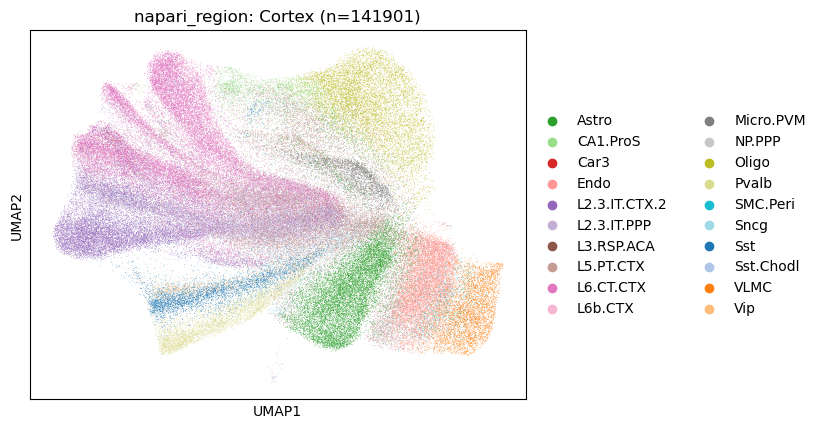

In [17]:
figs=ezy.plot.umap(
    adata= adata_full[(adata_full.obs['napari_region']=='Cortex') | (adata_full.obs['tissue']=='Cortex')],
    cluster_key= "cell_type",

    group_by1= "tissue",
    group_by1_list= ["Cortex"],

    group_by2= "napari_region",
    group_by2_list= ["Cortex"],
    
    n_top_clusters= 20,
    n_neighbors = 25,
    n_pcs = 20,
    random_state = 0,
    legend_fontsize= 10,
    show = True#,
    #save: Optional[str] = None,   # e.g. "umap_by_group.png" or None
)

In [ ]:
figs=ezy.plot.umap(
    adata= adata_full,
    cluster_key= "cell_type",

    group_by1= "tissue",
    group_by1_list= ["Cerebellum"],

    group_by2= "napari_region",
    group_by2_list= ["Cerebellum"],
    
    n_top_clusters= 20,
    n_neighbors = 25,
    n_pcs = 50,
    random_state = 0,
    legend_fontsize= 10,
    show = True#,
    #save: Optional[str] = None,   # e.g. "umap_by_group.png" or None
)